# From Inner Product to Cosine Similarity

## The duality of linear algebra

- We can think of vectors as physical arrows pointing some direction in space, or as a linear transformation of space!
- Depending on what we want to consider observations vs variables, sometimes we will think of $X=[x_i,...x_n]$ and $Y=[y_i,...y_n]$ as n 2-component vectors (i.e. multiple points in 2D space, which is probably how you are used to thinking about correlation) OR as the transpose, two n-dimensional vectors (which will help when we think about cosine similarity)

## The dot product, plotted
- How does the algebra of "element-wise multiplication and sum" translate to angles and geometry?

## Covariance Has Units
- When we consider a quantity like a covariance, we're multiplying two units together:
$$
\text{cov}(X,Y) = \frac{1}{N} \sum_{i=1}^n (x_i - M(X))(y_i - M(Y))
$$
- This creates issues: How do you compare "pounds $\times$ celsius" to "joules $\times$ dollars"?
- To address this, we often **normalize** 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/metabric.csv')
df.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Chemotherapy,Hormone Therapy,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Overall Survival Status,Radio Therapy,TMB (nonsynonymous),Tumor Size,Tumor Stage
0,43.19,BREAST CONSERVING,Breast Cancer,NO,YES,0.0,2.0,4.020,84.633333,0:LIVING,YES,2.615035,10.0,1.0
1,48.87,MASTECTOMY,Breast Cancer,YES,YES,1.0,2.0,4.030,163.700000,1:DECEASED,NO,2.615035,15.0,2.0
2,47.68,MASTECTOMY,Breast Cancer,YES,YES,3.0,1.0,4.050,164.933333,0:LIVING,YES,1.307518,25.0,2.0
3,76.97,MASTECTOMY,Breast Cancer,YES,YES,8.0,2.0,6.080,41.366667,1:DECEASED,YES,2.615035,40.0,2.0
4,78.77,MASTECTOMY,Breast Cancer,NO,YES,0.0,4.0,4.062,7.800000,1:DECEASED,YES,5.230071,31.0,4.0


In [2]:
vars = ['Age at Diagnosis', 'Lymph nodes examined positive',
       'Mutation Count', 'Nottingham prognostic index',
       'Overall Survival (Months)',
       'TMB (nonsynonymous)', 'Tumor Size', 'Tumor Stage']
vcv = df[vars].cov()
vcv

,Age at Diagnosis,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),TMB (nonsynonymous),Tumor Size,Tumor Stage
Age at Diagnosis,168.125720,1.562205,0.859348,-0.783552,-168.322852,0.978979,14.315359,0.848241
Lymph nodes examined positive,1.562205,14.876068,-1.061885,2.484143,-78.593696,-1.394084,18.188923,1.071196
Mutation Count,0.859348,-1.061885,14.104104,-0.055697,21.069243,18.390594,0.684915,-0.057670
Nottingham prognostic index,-0.783552,2.484143,-0.055697,1.268082,-22.772707,-0.073378,5.235193,0.380761
Overall Survival (Months),-168.322852,-78.593696,21.069243,-22.772707,6129.361077,27.982285,-244.009175,-13.293022
TMB (nonsynonymous),0.978979,-1.394084,18.390594,-0.073378,27.982285,24.012383,0.727712,-0.079349
Tumor Size,14.315359,18.188923,0.684915,5.235193,-244.009175,0.727712,217.703843,4.757030
Tumor Stage,0.848241,1.071196,-0.057670,0.380761,-13.293022,-0.079349,4.757030,0.385566


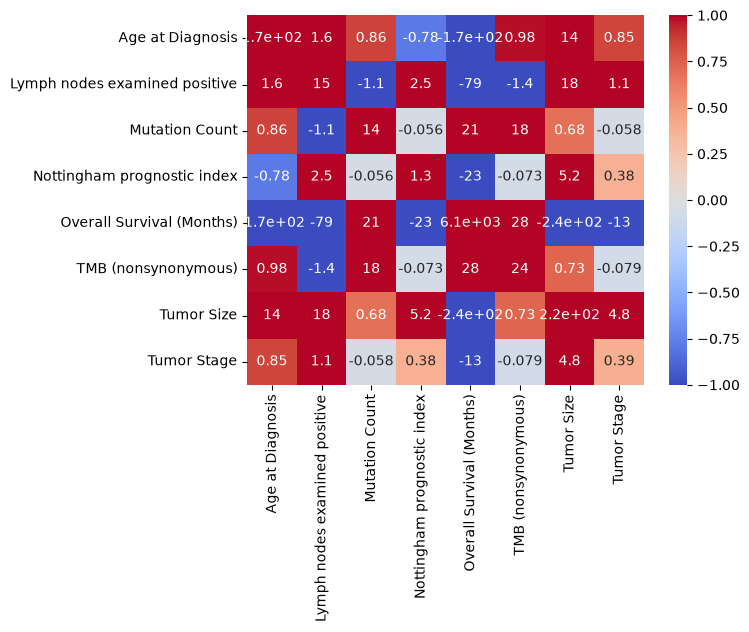

In [3]:
sns.heatmap(
    vcv,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.show()

In [4]:
plan = ['Chemotherapy', 'Hormone Therapy','Radio Therapy']
tdf = df[plan]
vcv = pd.get_dummies(tdf,drop_first=True).cov()
vcv

,Chemotherapy_YES,Hormone Therapy_YES,Radio Therapy_YES
Chemotherapy_YES,0.167731,-0.026608,0.044203
Hormone Therapy_YES,-0.026608,0.239389,0.017116
Radio Therapy_YES,0.044203,0.017116,0.224658


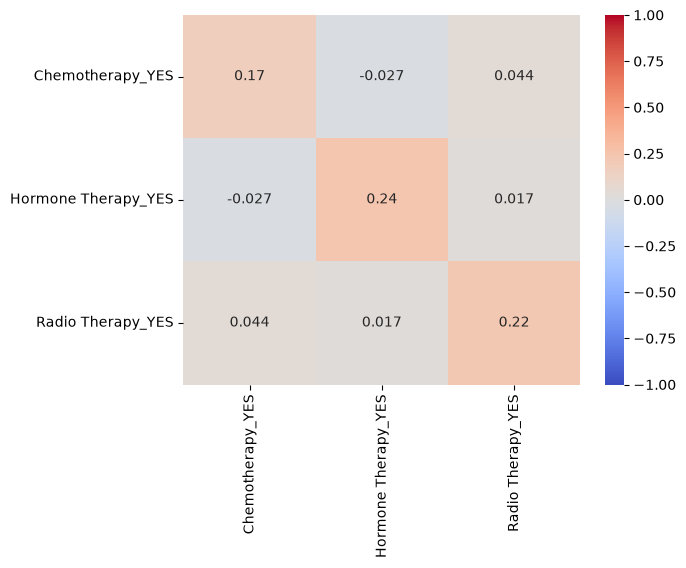

In [5]:
sns.heatmap(
    vcv,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.show()

## Correlation
- The **correlation** of $X$ and $Y$ is:
$$
\text{corr}_{xy} = \dfrac{\frac{1}{N} \sum_{i=1}^n (x_i - M(X))(y_i - M(Y))}{ \sqrt{\frac{1}{N} \sum_{i=1}^n (x_i - M(X))^2} \times \sqrt{\frac{1}{N} \sum_{i=1}^n (y_i - M(Y))^2} } = \dfrac{\text{cov}(X,Y)}{\sqrt{\mathbb{V}[X]}\sqrt{\mathbb{V}[Y]}}
$$
- There is a thing called the Cauchy-Schwarz inequality that guarantees that the correlation is bounded between -1 and 1
- When do two vectors have 0 correlation?
- Notice that $X$ and $Y$ appear in the numerator and denominator, so the units "cancel out": This is dimensionless

In [6]:
vars = ['Age at Diagnosis', 'Lymph nodes examined positive',
       'Mutation Count', 'Nottingham prognostic index',
       'Overall Survival (Months)',
       'TMB (nonsynonymous)', 'Tumor Size', 'Tumor Stage']
corr_matrix = df[vars].corr()
corr_matrix

,Age at Diagnosis,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),TMB (nonsynonymous),Tumor Size,Tumor Stage
Age at Diagnosis,1.000000,0.031238,0.017647,-0.053663,-0.165813,0.015408,0.074826,0.105354
Lymph nodes examined positive,0.031238,1.000000,-0.073310,0.571951,-0.260277,-0.073761,0.319617,0.447276
Mutation Count,0.017647,-0.073310,1.000000,-0.013170,0.071659,0.999322,0.012360,-0.024730
Nottingham prognostic index,-0.053663,0.571951,-0.013170,1.000000,-0.258305,-0.013298,0.315084,0.544540
Overall Survival (Months),-0.165813,-0.260277,0.071659,-0.258305,1.000000,0.072939,-0.211235,-0.273443
TMB (nonsynonymous),0.015408,-0.073761,0.999322,-0.013298,0.072939,1.000000,0.010065,-0.026078
Tumor Size,0.074826,0.319617,0.012360,0.315084,-0.211235,0.010065,1.000000,0.519222
Tumor Stage,0.105354,0.447276,-0.024730,0.544540,-0.273443,-0.026078,0.519222,1.000000


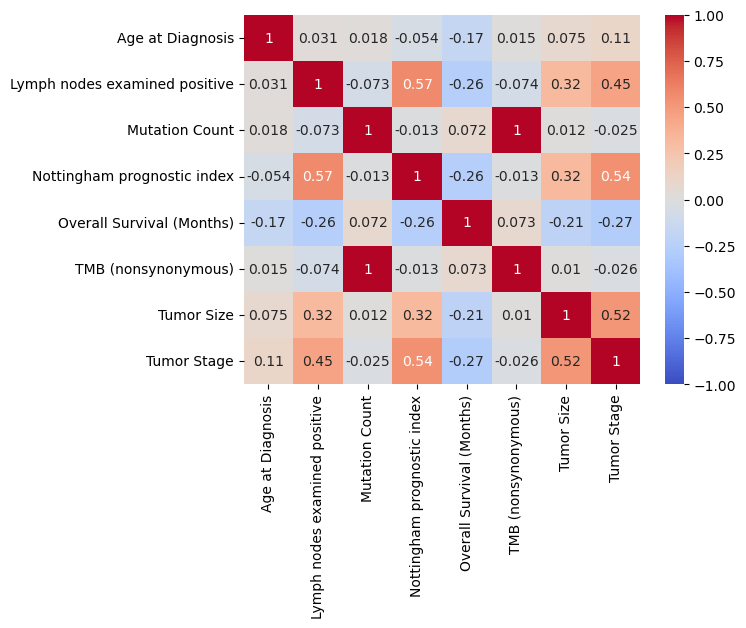

In [25]:
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.show()

In [26]:
plan = ['Chemotherapy', 'Hormone Therapy','Radio Therapy']
tdf = df[plan]
corr_matrix = pd.get_dummies(tdf,drop_first=True).corr()
corr_matrix

,Chemotherapy_YES,Hormone Therapy_YES,Radio Therapy_YES
Chemotherapy_YES,1.000000,-0.132784,0.227713
Hormone Therapy_YES,-0.132784,1.000000,0.073805
Radio Therapy_YES,0.227713,0.073805,1.000000


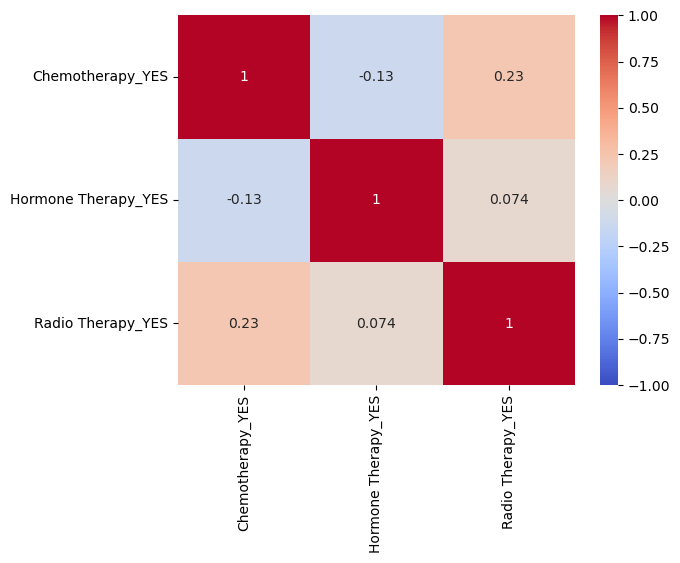

In [27]:
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.show()

## Correlation
- Define $c_x = X - M(X)$ and $c_y = Y - M(Y)$
- Then the correlation is
$$
\begin{alignat*}{2}
\text{corr}_{xy} &=& \dfrac{\frac{1}{n} \sum_{i=1}^n (x_i - M(X))(y_i - M(Y))}{ \sqrt{\frac{1}{n} \sum_{i=1}^n (x_i - M(X))^2} \times \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - M(Y))^2} } \quad \text{(Definition)}\\
&=& \dfrac{\frac{1}{n} c_x \cdot c_y}{ \sqrt{\frac{1}{n} c_x \cdot c_x} \times \sqrt{\frac{1}{n} c_y \cdot c_y}} \quad \text{(Substitute $c_x$, $c_y$; Convert to dot product)}\\
&=& \dfrac{c_x \cdot c_y}{ \sqrt{ c_x \cdot c_x} \times \sqrt{ c_y \cdot c_y}} \quad \text{(Cancel $n$'s)}\\
&=& \dfrac{c_x \cdot c_y}{ ||c_x|| \times ||c_y||} \quad \text{(Convert to length)}
\end{alignat*}
$$
- The correlation between $X$ and $Y$ can be expressed as a dot product, divided by the length of the two vectors

## Cosine Similarity
- That quantity is called the **cosine similarity**:
$$
\cos(\theta_{vw}) = \dfrac{ v \cdot w}{ ||v|| \times ||w||} 
$$
- This is an incredibly powerful concept: The "correlation" between any two vectors $v$ and $w$ is essentially the inner product divided by the two lengths
- This works in any number of dimensions: We can use it for images, text, or more conventional tabular data

## Notice
- To motivate cosine similarity, we showed how it can be derived from vector space operations and correlation, but cosine similarity and correlation are typically not identical
- The difference in practice is that correlation is centered, and cosine similarity is not:
$$
\text{corr}(x,y) = \dfrac{c_x \cdot c_y}{||c_x|| \times ||c_y||} \quad \text{ versus } \quad \text{cos\_sim}(x,y) = \dfrac{x \cdot y}{||x|| \times ||y||}
$$
- So: Correlation is centered, cosine similarity is not

## The Lab
- The lab applies the concept of cosine similarity to the problem of data retrieval
- The vectors we are focusing on the counts of words in songs: Every song is essentially a histogram of words
- When we multiply those histograms together with the inner product, we get a measure of shared word-count mass; after centering, the same structure becomes covariance
- When we normalize and compute the cosine similarity, we account for song length
- This is the backbone of modern information retrieval (How do LLMs know about your previous conversations or today's news? Those aren't trained into the weights) 